<a href="https://colab.research.google.com/github/yshzjq/Step-2.Statistical_Thinking-Machine-Learning/blob/main/Step%202.%20%ED%86%B5%EA%B3%84%EC%A0%81%20%EC%82%AC%EA%B3%A0%EC%99%80%20%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%20%EC%9E%85%EB%AC%B8/1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 처리용
import pandas as pd
import numpy as np

# 시각화용
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 계산용
from scipy import stats

In [2]:
# 데이터 URL
url ="/content/online_retail_II.xlsx"

# CSV 파일 읽기
df = pd.read_excel(url) # 파일 확장자가 엑셀이라서 함수가 바뀜

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# 매출액 계산
df['sales'] = df['Quantity'] * df['Price']

# 음수 제거 (환불 등)
df = df[df['sales'] >0]

df[['Quantity','Price','sales']].head()


,Quantity,Price,sales
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


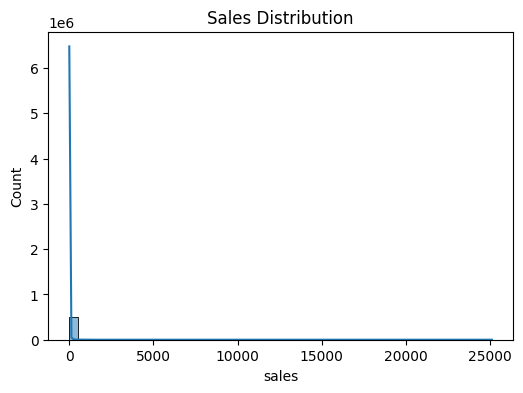

In [4]:
plt.figure(figsize=(6,4))

# 매출 분포 히스토그램
sns.histplot(df['sales'], bins=50, kde=True)
# bins는 구간 개수 (bin이 너무 많으면 노이즈 증가, 너무 적으면 모양 뭉개짐)
# kde = Kernel Density Estimation -> 히스토그램 위에 부드러운 형태의 분포 곡선 추가

plt.title('Sales Distribution')
plt.show()

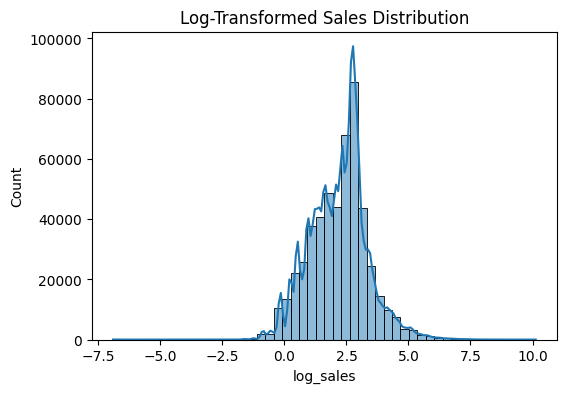

In [5]:
# 로그 변환
df['log_sales'] = np.log(df['sales'])

plt.figure(figsize=(6,4))
sns.histplot(df['log_sales'], bins=50, kde=True)
plt.title('Log-Transformed Sales Distribution')
plt.show()



In [6]:
# Z-score 계산
df['z_score'] = stats.zscore(df['log_sales'])

df[['log_sales','z_score']].head()



,log_sales,z_score
0,4.423648,1.918596
1,4.394449,1.893446
2,4.394449,1.893446
3,4.613138,2.081812
4,3.401197,1.037915


In [7]:
# 이상치 기준
threshold =3

# 이상치 필터링
outliers = df[abs(df['z_score']) >= threshold]

outliers.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sales,log_sales,z_score
67,489438,85132A,CHARLIE + LOLA BISCUITS TINS,60,2009-12-01 09:24:00,6.38,18102.0,United Kingdom,382.8,5.947513,3.231167
68,489438,85132C,CHARLIE AND LOLA FIGURES TINS,60,2009-12-01 09:24:00,6.40,18102.0,United Kingdom,384.0,5.950643,3.233863
575,489523,84879,ASSORTED COLOUR BIRD ORNAMENT,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,1160.0,7.056175,4.186106
934,489539,22086,PAPER CHAIN KIT 50'S CHRISTMAS,160,2009-12-01 12:18:00,2.55,15061.0,United Kingdom,408.0,6.011267,3.286081
935,489539,22083,PAPER CHAIN KIT RETRO SPOT,160,2009-12-01 12:18:00,2.55,15061.0,United Kingdom,408.0,6.011267,3.286081


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


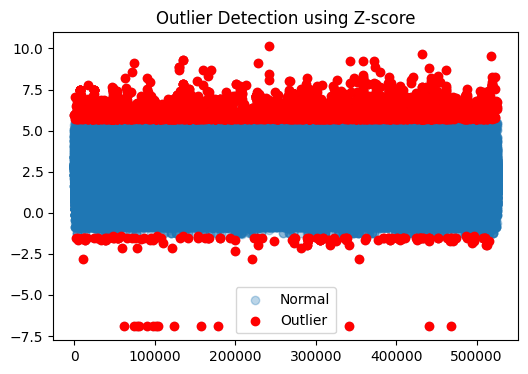

In [8]:
plt.figure(figsize=(6,4))

# 전체 데이터
plt.scatter(df.index, df['log_sales'], alpha=0.3, label='Normal')

# 이상치 강조
plt.scatter(outliers.index, outliers['log_sales'], color='red', label='Outlier')

plt.legend()
plt.title('Outlier Detection using Z-score')
plt.show()



In [9]:
# 이상치 요약
outlier_report = outliers[['Invoice','StockCode','Quantity','Price','sales','z_score']]

outlier_report.describe()


,Quantity,Price,sales,z_score
count,2962.000000,2962.00000,2962.000000,2962.000000
mean,370.780891,119.52512,648.953951,3.097168
std,1018.045661,824.45369,958.011400,1.779290
min,1.000000,0.00100,0.001000,-7.841634
25%,54.250000,1.45000,330.000000,3.103326
50%,160.000000,2.55000,422.880000,3.316935
75%,300.000000,6.75000,672.900000,3.717037
max,19152.000000,25111.09000,25111.090000,6.834642


Index(['rpt_time_date', 'rpt_time_time', 'ads_idx', 'mda_idx', 'rpt_time_clk',
       'rpt_time_turn', 'rpt_time_scost', 'rpt_time_acost', 'rpt_time_cost',
       'rpt_time_earn'],
      dtype='object')
  rpt_time_date  rpt_time_time  ads_idx  mda_idx  rpt_time_clk  rpt_time_turn  \
0    2024-07-27              0     4418      761             1              0   
1    2024-07-27              0     7377      213             1              0   
2    2024-07-27              0     7377      337             1              0   
3    2024-07-27              0     7377      496             1              1   
4    2024-07-27              0     7528      792             1              0   

   rpt_time_scost  rpt_time_acost  rpt_time_cost  rpt_time_earn  
0               0               0              0              0  
1               0               0              0              0  
2               0               0              0              0  
3             230             230            1

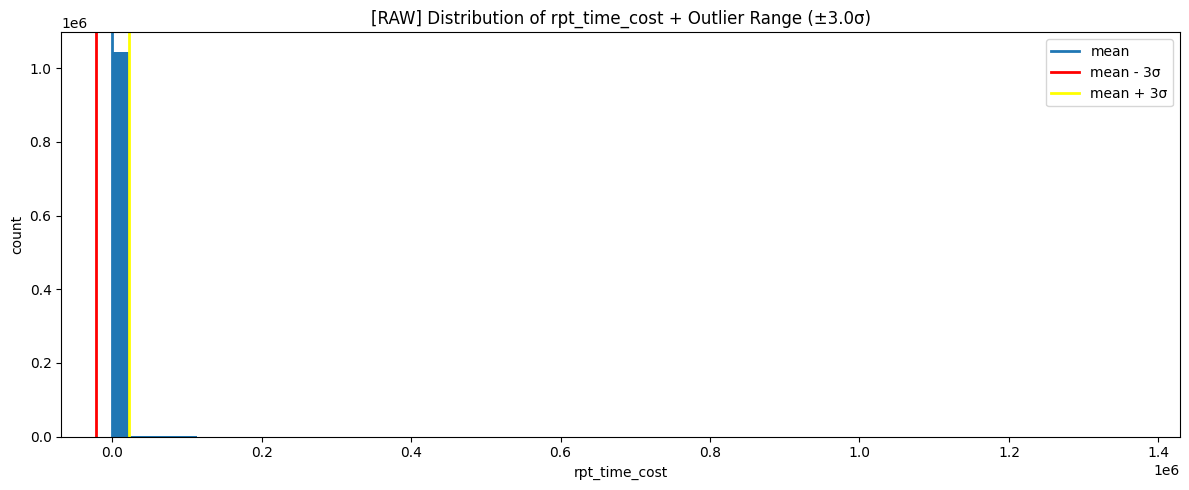

----- 원본 값 기준 -----
평균: 457.7195498652934
표준편차: 7276.06288794675
이상치 개수: 3431


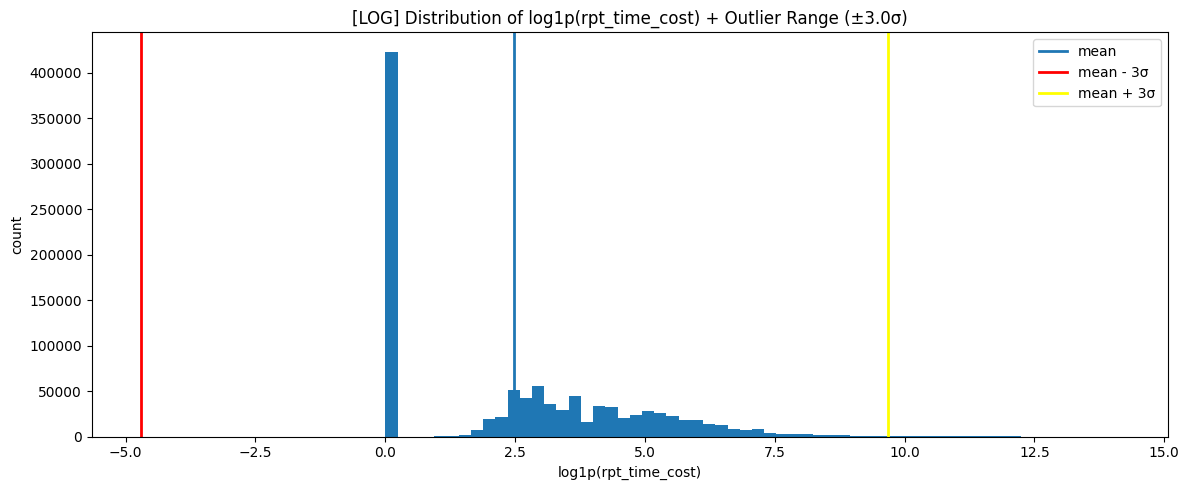

----- log 변환 값 기준 -----
평균: 2.4875317108346024
표준편차: 2.398777566326102
이상치 개수: 4217

[원본 기준] 이상치 레코드 상위 5개
     rpt_time_cost  z_score_raw
178          59415     8.102910
502          58420     7.966160
503         579360    79.562572
504         285600    39.189090
505         118320    16.198634

[log 기준] 이상치 레코드 상위 5개
     rpt_time_cost  z_score_log
178          59415     3.545467
502          58420     3.538427
503         579360     4.494852
504         285600     4.199981
505         118320     3.832629

저장 완료:
outliers_raw.csv
outliers_log.csv


In [12]:

# 라이브러리 불러오기

import pandas as pd                 # 데이터 처리용
import numpy as np                  # 수치 계산용
import matplotlib.pyplot as plt     # 시각화용


# 데이터 불러오기

FILE_PATH = "/content/real_data_sheet1.xlsx"
df = pd.read_excel(FILE_PATH)        # CSV 파일 읽어옴

# 컬럼 확인함
print(df.columns)
print(df.head())


# 분포를 볼 숫자 컬럼 선택
# - 보통 비용/수익이 분포+이상치 실습에 좋음

TARGET_COL = "rpt_time_cost"        # 분포/이상치를 볼 컬럼 (원하면 "rpt_time_earn"으로 바꿔도 됨)

# 결측 제거
x_raw = df[TARGET_COL].dropna()

# 값이 너무 큰 꼬리(우측 꼬리)가 있으면 정규성이 깨지기 쉬움
# 그래서 log(1+x) 변환도 같이 준비 (0도 처리 가능)
x_log = np.log1p(x_raw)


# 정규분포(가정) 기반 이상치 탐지 함수 만들기
# - z-score = (x - 평균) / 표준편차
# - |z| >= 3 이면 이상치로 보는 3-sigma 규칙 적용

def detect_outliers_normal(series, z_thresh=3.0):
    # 평균 계산
    mu = series.mean()

    # 표준편차 계산 (표본표준편차 ddof=1 사용)
    sigma = series.std(ddof=1)

    # 표준편차가 0이면 계산 불가하니 예외 처리
    if sigma == 0 or np.isnan(sigma):
        # 이상치가 없다고 반환
        return mu, sigma, pd.Series(False, index=series.index), pd.Series(np.nan, index=series.index)

    # z-score 계산
    z = (series - mu) / sigma

    # 이상치 여부 계산
    is_outlier = z.abs() >= z_thresh

    return mu, sigma, is_outlier, z


# (1) 분포 그리기 + (2) 이상치 구간 표시 (원본 값 기준)

Z_THRESH = 3.0   # 3-sigma 규칙 적용

mu_raw, sigma_raw, is_out_raw, z_raw = detect_outliers_normal(x_raw, z_thresh=Z_THRESH)

# 히스토그램 그림
plt.figure(figsize=(12, 5))
plt.hist(x_raw, bins=60)  # 분포 그려줌 (구간 60개로 나눔)

# 평균선 그려줌
plt.axvline(mu_raw, linewidth=2, label="mean")

# 평균 ± 3표준편차 선 그려줌 (이 구간 밖이 이상치 구간)
plt.axvline(mu_raw - Z_THRESH * sigma_raw, linewidth=2, label="mean - 3σ", color = 'red')
plt.axvline(mu_raw + Z_THRESH * sigma_raw, linewidth=2, label="mean + 3σ", color = 'yellow')

plt.title(f"[RAW] Distribution of {TARGET_COL} + Outlier Range (±{Z_THRESH}σ)")
plt.xlabel(TARGET_COL)
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

print("----- 원본 값 기준 -----")
print("평균:", mu_raw)
print("표준편차:", sigma_raw)
print("이상치 개수:", int(is_out_raw.sum()))


# (1) 분포 그리기 + (2) 이상치 구간 표시 (log 변환 값 기준)
# - log 변환하면 정규분포에 더 가까워지는 경우 많음

mu_log, sigma_log, is_out_log, z_log = detect_outliers_normal(x_log, z_thresh=Z_THRESH)

plt.figure(figsize=(12, 5))
plt.hist(x_log, bins=60)

plt.axvline(mu_log, linewidth=2, label="mean")
plt.axvline(mu_log - Z_THRESH * sigma_log, linewidth=2, label="mean - 3σ", color = 'red')
plt.axvline(mu_log + Z_THRESH * sigma_log, linewidth=2, label="mean + 3σ", color = 'yellow')

plt.title(f"[LOG] Distribution of log1p({TARGET_COL}) + Outlier Range (±{Z_THRESH}σ)")
plt.xlabel(f"log1p({TARGET_COL})")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

print("----- log 변환 값 기준 -----")
print("평균:", mu_log)
print("표준편차:", sigma_log)
print("이상치 개수:", int(is_out_log.sum()))


# (3) 이상치 레코드 추출하기
# - 원본 기준 이상치 / log 기준 이상치를 각각 뽑아볼 수 있게 함


# 원본 값 기준 이상치 레코드 추출
df_out_raw = df.loc[x_raw.index[is_out_raw]].copy()

# log 변환 기준 이상치 레코드 추출
df_out_log = df.loc[x_log.index[is_out_log]].copy()

# 이상치에 z-score 정보도 붙여서 “왜 이상치인지” 보이게 함
df_out_raw["z_score_raw"] = z_raw[is_out_raw].values
df_out_log["z_score_log"] = z_log[is_out_log].values

print("\n[원본 기준] 이상치 레코드 상위 5개")
print(df_out_raw[[TARGET_COL, "z_score_raw"]].head())

print("\n[log 기준] 이상치 레코드 상위 5개")
print(df_out_log[[TARGET_COL, "z_score_log"]].head())


# 이상치 레코드를 파일로 저장하기 (실무형 결과물)

df_out_raw.to_csv("outliers_raw.csv", index=False, encoding="utf-8-sig")
# encoding을 utf-8-sig로 둔 이유는 윈도우에서 엑셀 열 때 한글 깨지지 않도록 하기 위함
# index를 false로 한 이유는 pandas 인덱스를 컬럼어로 저장하는일을 방지하기 위해
df_out_log.to_csv("outliers_log.csv", index=False, encoding="utf-8-sig")

print("\n저장 완료:")
print("outliers_raw.csv")
print("outliers_log.csv")
